### Import librairies

In [129]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtr, ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

from python_module.pricing_model import BSMModel, SABRModel

### Custom functions

In [130]:
# Functions used across the notebook. They read notebook variables defined in the sections below,
# so they can be defined here and called once those sections have run.

# --- Monte Carlo simulation ---
def simulate_sabr_paths(F0, T, alpha, beta, rho, nu, n_steps, n_paths, seed=None):
    """Simulate SABR forward and vol paths: dF = sigma * F^beta * dW, dsigma = nu * sigma * dZ, d<W, Z> = rho dt.

    The vol is simulated exactly (lognormal) and the forward with a log-Euler step, which keeps F > 0.
    Returns (F_paths, sigma_paths) as DataFrames indexed by time (years), one column per path.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    dW = rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)
    dZ = rho * dW + np.sqrt(1 - rho ** 2) * rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)

    F = np.empty((n_steps + 1, n_paths))
    sigma = np.empty((n_steps + 1, n_paths))
    F[0], sigma[0] = F0, alpha
    for i in range(n_steps):
        local_vol = sigma[i] * F[i] ** (beta - 1)       # lognormal vol of F over the step
        F[i + 1] = F[i] * np.exp(local_vol * dW[i] - 0.5 * local_vol ** 2 * dt)
        sigma[i + 1] = sigma[i] * np.exp(nu * dZ[i] - 0.5 * nu ** 2 * dt)

    times = np.linspace(0, T, n_steps + 1)
    return pd.DataFrame(F, index=times), pd.DataFrame(sigma, index=times)


# --- Pricing (vectorised Hagan SABR vol + Black-76) ---
def sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. (2002) lognormal implied vol, vectorised over K."""
    K = np.asarray(K, dtype=float)
    fk_pow = (F * K) ** (0.5 * (1 - beta))
    log_fk = np.log(F / K)
    z = nu / alpha * fk_pow * log_fk
    x = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    small = np.abs(z) < 1e-7
    z_over_x = np.where(small, 1.0, z / np.where(small, 1.0, x))
    denom = fk_pow * (1 + (1 - beta) ** 2 / 24 * log_fk ** 2 + (1 - beta) ** 4 / 1920 * log_fk ** 4)
    corr = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / fk_pow ** 2
                + 0.25 * rho * beta * nu * alpha / fk_pow
                + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return alpha / denom * z_over_x * corr


def black_price(F, K, T, vol, is_call, r=0.0):
    """Discounted Black-76 price, vectorised over K. T <= 0 returns intrinsic."""
    K = np.asarray(K, dtype=float)
    if T <= 0:
        return np.where(is_call, np.maximum(F - K, 0.0), np.maximum(K - F, 0.0))
    sd = vol * np.sqrt(T)
    d1 = np.log(F / K) / sd + 0.5 * sd
    call = F * ndtr(d1) - K * ndtr(d1 - sd)
    return np.exp(-r * T) * np.where(is_call, call, call - (F - K))


def portfolio_pv(weights, F, T_left, alpha, beta, rho, nu):
    """PV of a portfolio of options (weights indexed by (option_type, strike)) under SABR."""
    strikes = weights.index.get_level_values("strike").to_numpy()
    is_call = weights.index.get_level_values("option_type").to_numpy() == "call"
    vol = sabr_vol(F, strikes, max(T_left, 1e-12), alpha, beta, rho, nu)
    return weights.to_numpy() @ black_price(F, strikes, T_left, vol, is_call, r)



def bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu, rel_bump=1e-4):
    """PVs at F - h, F, F + h, with alpha moving along its expected shift dalpha = rho * nu / F^beta * dF (Bartlett 2006)."""
    h = F * rel_bump
    d_alpha = rho * nu / F ** beta * h
    down = portfolio_pv(weights, F - h, T_left, alpha - d_alpha, beta, rho, nu)
    base = portfolio_pv(weights, F, T_left, alpha, beta, rho, nu)
    up = portfolio_pv(weights, F + h, T_left, alpha + d_alpha, beta, rho, nu)
    return down, base, up, h


def bartlett_delta(weights, F, T_left, alpha, beta, rho, nu):
    """SABR delta including the forward / vol correlation (Bartlett 2006): dPV/dF + dPV/dalpha * rho * nu / F^beta."""
    down, _, up, h = bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu)
    return (up - down) / (2 * h)


def bartlett_gamma_cash(weights, F, T_left, alpha, beta, rho, nu):
    """Gamma cash (Gamma * F^2 / 100, P&L per 1% move squared) with Gamma taken along the Bartlett direction."""
    down, base, up, h = bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu)
    return (up - 2 * base + down) / h ** 2 * F ** 2 / 100


def headline_risks(weights, F, T_left, alpha, bump=0.10):
    """Headline risks of a portfolio under the pricing SABR parameters (alpha = current vol):
    bartlett_delta, gamma_cash, and PV(param * (1 + bump)) - PV(param) for alpha, rho and nu."""
    params = {"alpha": alpha, "beta": pricing_beta, "rho": pricing_rho, "nu": pricing_nu}
    base = portfolio_pv(weights, F, T_left, **params)
    return {
        "bartlett_delta": bartlett_delta(weights, F, T_left, **params),
        "gamma_cash": bartlett_gamma_cash(weights, F, T_left, **params),
        **{name: portfolio_pv(weights, F, T_left, **{**params, name: params[name] * (1 + bump)}) - base
           for name in ("alpha", "rho", "nu")},
    }

# --- Benchmark portfolio ---
# Target payoffs replicated by the strip, as a function of terminal spot S and the strip centre S_star.
BENCHMARK_PAYOFFS = {
    "variance_swap": lambda S, S_star: 2 / T * ((S - S_star) / S_star - np.log(S / S_star)),
    "gamma_swap": lambda S, S_star: 2 / T * (S / S_star * np.log(S / S_star) - S / S_star + 1),
}


def delta_to_strike(delta, F, alpha, T_left):
    """Strike of a Black-76 delta (negative: put delta, positive: call delta) at the SABR ATM vol."""
    atm_sd = sabr_vol(F, F, T_left, alpha, pricing_beta, pricing_rho, pricing_nu) * np.sqrt(T_left)
    call_delta = np.where(np.asarray(delta) < 0, 1 + np.asarray(delta) / np.exp(-r * T_left), np.asarray(delta) / np.exp(-r * T_left))
    return F * np.exp(-ndtri(call_delta) * atm_sd + 0.5 * atm_sd ** 2)


def delta_strike_bounds(min_delta_strike, max_delta_strike, F, alpha, T_left):
    """Strikes of the min (put) and max (call) delta."""
    return delta_to_strike(min_delta_strike, F, alpha, T_left), delta_to_strike(max_delta_strike, F, alpha, T_left)


def grid_strikes(K_lower, K_upper, K_ref, dK):
    """Nodes of the fixed strike grid K_ref + k * dK lying inside [K_lower, K_upper]."""
    k = np.arange(np.ceil((K_lower - K_ref) / dK), np.floor((K_upper - K_ref) / dK) + 1)
    return np.round(K_ref + k * dK, 10)


def otm_index(strikes, F):
    """(option_type, strike) index: puts below the grid node closest to F, calls from it upwards."""
    S_star = strikes[np.argmin(np.abs(strikes - F))]
    return pd.MultiIndex.from_arrays(
        [np.where(strikes < S_star, "put", "call"), strikes], names=["option_type", "strike"]
    )


def strip_weights(portfolio_type, strikes, F):
    """Option strip replicating the benchmark payoff on an equally spaced strike grid.

    Weights are the kinks of the piecewise-linear interpolant of the payoff on the strikes, with one
    ghost node on each side so the boundary strikes carry weight. The payoff is centred on the node closest to F.
    """
    dK = strikes[1] - strikes[0]
    S_star = strikes[np.argmin(np.abs(strikes - F))]
    nodes = np.concatenate([[strikes[0] - dK], strikes, [strikes[-1] + dK]])
    slopes = np.diff(BENCHMARK_PAYOFFS[portfolio_type](nodes, S_star)) / np.diff(nodes)
    return pd.Series(np.diff(slopes), index=otm_index(strikes, F))


def track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, universe_update=None, bump=0.10):
    """Hold an option portfolio along one path, delta hedged every step with the forward.

    new_weights(t, F, alpha, T_left, current) -> weights Series indexed by (option_type, strike), called at t0 and every
    rebalancing_frequency steps (None: t0 only); current is the portfolio held so far (None at t0). universe_update(F, alpha, T_left) -> index of strikes to add to the
    universe at each step (listed with 0 weight when not held).
    Returns:
        weights: (option_type, strike) x time, weight held from each date to the next
                 (0 when in the universe but not held, NaN before the strike joins the universe)
        headline_risk: time x (bartlett_delta, gamma_cash, alpha, rho, nu) of the held portfolio (see headline_risks)
        pnl: time x (option_pnl, delta_hedge_pnl, total_pnl), P&L over the step ending at each date of the portfolio
             held from the previous date: option_pnl = PV change of the options, delta_hedge_pnl = -bartlett_delta *
             dF (forward hedge rebalanced every step), total_pnl = option_pnl + delta_hedge_pnl (0 at t0).
             Rebalancing trades at the pricing PV, so it adds no P&L.
    """
    universe = pd.MultiIndex.from_arrays([[], []], names=["option_type", "strike"])
    holdings, risks, pnls = {}, {}, {}
    current = None
    pricing_params = {"beta": pricing_beta, "rho": pricing_rho, "nu": pricing_nu}
    for i, t in enumerate(forward_ts.index):
        F, alpha, T_left = forward_ts[t], sigma_ts[t], T - t
        if current is None:
            pnls[t] = {"option_pnl": 0.0, "delta_hedge_pnl": 0.0}
        else:
            pnls[t] = {
                "option_pnl": portfolio_pv(current, F, T_left, alpha, **pricing_params) - held_pv,
                "delta_hedge_pnl": -held_delta * (F - held_F),
            }
        if T_left > 1e-12:
            if universe_update is not None:
                universe = universe.union(universe_update(F, alpha, T_left))
            if current is None or (rebalancing_frequency is not None and i % rebalancing_frequency == 0):
                current = new_weights(t, F, alpha, T_left, current)
        current = current.reindex(universe.union(current.index), fill_value=0.0)
        holdings[t] = current
        risks[t] = headline_risks(current, F, T_left, alpha, bump)
        held_pv, held_delta, held_F = portfolio_pv(current, F, T_left, alpha, **pricing_params), risks[t]["bartlett_delta"], F

    weights = pd.concat(holdings, axis=1).sort_index()
    headline_risk = pd.DataFrame.from_dict(risks, orient="index")
    pnl = pd.DataFrame.from_dict(pnls, orient="index")
    pnl["total_pnl"] = pnl["option_pnl"] + pnl["delta_hedge_pnl"]
    return weights, headline_risk, pnl


def benchmark_portfolio_creation(portfolio_type, min_delta_strike, max_delta_strike, n_options, forward_ts, sigma_ts,
                                 rebalancing_frequency, sizing=None, bump=0.10):
    """Benchmark option strip along one path, delta hedged with the forward (see track_portfolio for the outputs).

    The option universe lives on a fixed strike grid (n_options nodes between the delta bounds at t0). At each step
    the grid nodes inside the current delta bounds that are not yet in the universe are added (with 0 weight unless
    re-struck). Every rebalancing_frequency steps the strip is re-struck on the current in-range nodes around the
    current forward; with rebalancing_frequency=None the initial weights are held to expiry.
    sizing: {risk: quantity}, e.g. {"gamma_cash": 50_000_000}. Each new strip (t0 and every re-strike) is scaled so
    that this headline risk equals quantity when it is struck. None keeps the unit replication weights.
    Pricing uses the pricing SABR parameters with alpha set to the path's current vol sigma_ts.
    """
    if sizing is not None and len(sizing) != 1:
        raise ValueError(f"sizing must have exactly one {{risk: quantity}} entry, got {sizing}")

    K_lower, K_upper = delta_strike_bounds(min_delta_strike, max_delta_strike, forward_ts.iloc[0], sigma_ts.iloc[0], T)
    K_ref, dK = K_lower, (K_upper - K_lower) / (n_options - 1)

    def in_range_strikes(F, alpha, T_left):
        return grid_strikes(*delta_strike_bounds(min_delta_strike, max_delta_strike, F, alpha, T_left), K_ref, dK)

    def new_weights(t, F, alpha, T_left, current):
        weights = strip_weights(portfolio_type, in_range_strikes(F, alpha, T_left), F)
        if sizing is not None:
            (risk, quantity), = sizing.items()
            weights *= quantity / headline_risks(weights, F, T_left, alpha, bump)[risk]
        return weights

    def universe_update(F, alpha, T_left):
        return otm_index(in_range_strikes(F, alpha, T_left), F)

    return track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, universe_update, bump)


# --- Replication portfolio ---
def replication_portfolio_creation(min_delta_strike, max_delta_strike, forward_ts, sigma_ts, rebalancing_frequency,
                                   benchmark_risk, target_deltas, bump=0.10):
    """Few-option portfolio matching the benchmark headline risks, delta hedged with the forward.

    Options are struck at the target deltas (negative: put delta, positive: call delta), which must lie inside the
    [min_delta_strike, max_delta_strike] strike range: puts <= min_delta_strike, calls >= max_delta_strike.
    At t0 and every rebalancing_frequency steps (None: t0 only), options at the current target delta strikes are traded
    on top of the existing portfolio (existing options are kept, not unwound) so that the non-delta headline risks
    (gamma_cash, alpha, rho, nu) of the whole portfolio equal benchmark_risk:
        A q = b - existing risk,  A[risk, option] = risk of one unit of each target delta option.
    The number of options held grows through time; when a target delta strike is already held, q is added to its
    quantity (which can change sign).
    bartlett_delta is not matched with options: it is hedged every step with the forward (delta_hedge_pnl).
    Returns weights, headline_risk, pnl as in track_portfolio.
    """
    risk_names = [name for name in benchmark_risk.columns if name != "bartlett_delta"]
    target_deltas = np.asarray(target_deltas, dtype=float)
    if len(target_deltas) != len(risk_names):
        raise ValueError(f"{len(risk_names)} target deltas needed to match {risk_names}, got {len(target_deltas)}")
    outside = target_deltas[((target_deltas < 0) & (target_deltas > min_delta_strike))
                            | ((target_deltas > 0) & (target_deltas < max_delta_strike)) | (target_deltas == 0)]
    if outside.size:
        raise ValueError(f"target deltas {outside} outside the [{min_delta_strike}, {max_delta_strike}] delta strike range")
    option_types = np.where(target_deltas < 0, "put", "call")

    def new_weights(t, F, alpha, T_left, current):
        index = pd.MultiIndex.from_arrays(
            [option_types, delta_to_strike(target_deltas, F, alpha, T_left)], names=["option_type", "strike"]
        )
        unit_risks = pd.DataFrame({
            key: headline_risks(pd.Series([1.0], index=index[[j]]), F, T_left, alpha, bump)
            for j, key in enumerate(index)
        }).loc[risk_names]
        target = benchmark_risk.loc[t, risk_names]
        if current is not None:
            target = target - pd.Series(headline_risks(current, F, T_left, alpha, bump))[risk_names]
        trades = pd.Series(np.linalg.solve(unit_risks.to_numpy(), target.to_numpy()), index=index)
        return trades if current is None else current.add(trades, fill_value=0.0)

    return track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, bump=bump)


### Inputs

In [131]:
# Market parameters
F0 = 100.0                                  # forward (spot = forward, no carry)
T = 252 / 252                                # maturity (years)
r = 0.00                                    # risk-free rate

# SABR parameters (Hagan 2002, lognormal backbone)
pricing_alpha = 0.20                                # initial vol level (~ ATM lognormal vol when beta = 1)
pricing_beta = 1.0                                  # CEV exponent: 1 = lognormal, 0 = normal
pricing_rho = -0.30                                 # spot / vol correlation (equity skew)
pricing_nu = 0.0080                                   # vol of vol

realized_alpha = 0.20                                # initial vol level (~ ATM lognormal vol when beta = 1)
realized_beta = 1.0                                  # CEV exponent: 1 = lognormal
realized_rho = -0.30                                 # spot / vol correlation (equity skew)
realized_nu = 0.0080                                   # vol of vol

# Option universe parameters
min_delta_strike = -0.01
max_delta_strike = 0.01
n_options = 100

# Replication portfolio parameters
replication_n_options = 10
replication_min_delta_strike = -0.1
replication_max_delta_strike = 0.1
replication_target_deltas = [-0.15, -0.35, 0.35, 0.15]   # one option per non-delta benchmark risk (put < 0, call > 0)
replication_rebalancing_frequency = 1       # trade the target delta options on top of the existing ones every n steps (None: t0 only)

# Benchmark portfolio parameters
portfolio_type = "variance_swap"           # "variance_swap" or "gamma_swap"
rebalancing_frequency = None                   # re-strike the strip around the forward every n steps (None: hold initial weights)
sizing = {"gamma_cash": 50_000_000}        # {risk: quantity} hit by each new strip (None: unit weights)

# Monte Carlo parameters
n_paths = 1_000                            # MC paths
n_steps = max(1, round(T * 252))            # MC steps (daily hedging)
seed = 42                                   # random seed

### Montecarlo Simulation

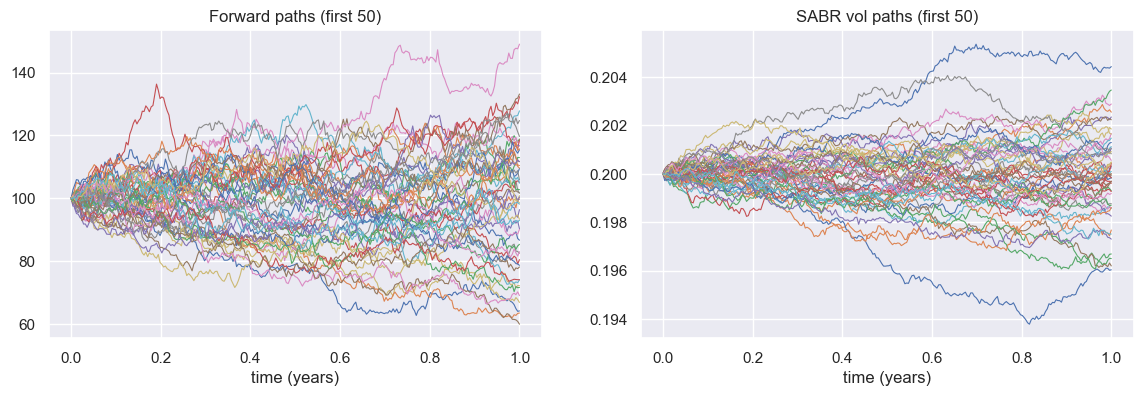

In [132]:
# Paths are simulated with the realized SABR parameters; options are priced with the pricing parameters.
F_paths, sigma_paths = simulate_sabr_paths(
    F0, T, realized_alpha, realized_beta, realized_rho, realized_nu, n_steps, n_paths, seed=seed
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
F_paths.iloc[:, :50].plot(ax=axes[0], legend=False, lw=0.8, title="Forward paths (first 50)")
sigma_paths.iloc[:, :50].plot(ax=axes[1], legend=False, lw=0.8, title="SABR vol paths (first 50)")
for ax in axes:
    ax.set_xlabel("time (years)")
plt.show()

### Benchmark Portfolio

0         0.003968  0.007937  0.0119    0.01587   \
option_type strike                                                     
call        99.84    509_077   509_077   509_077   509_077   509_077   
            100.8    499_092   499_092   499_092   499_092   499_092   
            101.8    489_397   489_397   489_397   489_397   489_397   
            102.8    479_983   479_983   479_983   479_983   479_983   
            103.8    470_838   470_838   470_838   470_838   470_838   
...                      ...       ...       ...       ...       ...   
put         94.88    563_799   563_799   563_799   563_799   563_799   
            95.87    552_171   552_171   552_171   552_171   552_171   
            96.86    540_898   540_898   540_898   540_898   540_898   
            97.86    529_967   529_967   529_967   529_967   529_967   
            98.85    519_364   519_364   519_364   519_364   519_364   

                    0.01984   0.02381   0.02778   0.03175   0.03571   ...  \
option_type strike                                                    ...   
call        99.84    509_077   509_077   509_077   509_077   509_077  ...   
            100.8    499_092   499_092   499_092   499_092   499_092  ...   
            101.8    489_397   489_397   489_397   489_397   489_397  ...   
            102.8    479_983   479_983   479_983   479_983   479_983  ...   
            103.8    470_838   470_838   470_838   470_838   470_838  ...   
...                      ...       ...       ...       ...       ...  ...   
put         94.88    563_799   563_799   563_799   563_799   563_799  ...   
            95.87    552_171   552_171   552_171   552_171   552_171  ...   
            96.86    540_898   540_898   540_898   540_898   540_898  ...   
            97.86    529_967   529_967   529_967   529_967   529_967  ...   
            98.85    519_364   519_364   519_364   519_364   519_364  ...   

                    0.9643    0.9683    0.9722    0.9762    0.9802    \
option_type strike                                                     
call        99.84    509_077   509_077   509_077   509_077   509_077   
            100.8    499_092   499_092   499_092   499_092   499_092   
            101.8    489_397   489_397   489_397   489_397   489_397   
            102.8    479_983   479_983   479_983   479_983   479_983   
            103.8    470_838   470_838   470_838   470_838   470_838   
...                      ...       ...       ...       ...       ...   
put         94.88    563_799   563_799   563_799   563_799   563_799   
            95.87    552_171   552_171   552_171   552_171   552_171   
            96.86    540_898   540_898   540_898   540_898   540_898   
            97.86    529_967   529_967   529_967   529_967   529_967   
            98.85    519_364   519_364   519_364   519_364   519_364   

                    0.9841    0.9881    0.9921    0.996     1         
option_type strike                                                    
call        99.84    509_077   509_077   509_077   509_077   509_077  
            100.8    499_092   499_092   499_092   499_092   499_092  
            101.8    489_397   489_397   489_397   489_397   489_397  
            102.8    479_983   479_983   479_983   479_983   479_983  
            103.8    470_838   470_838   470_838   470_838   470_838  
...                      ...       ...       ...       ...       ...  
put         94.88    563_799   563_799   563_799   563_799   563_799  
            95.87    552_171   552_171   552_171   552_171   552_171  
            96.86    540_898   540_898   540_898   540_898   540_898  
            97.86    529_967   529_967   529_967   529_967   529_967  
            98.85    519_364   519_364   519_364   519_364   519_364  

[100 rows x 253 columns]

,bartlett_delta,gamma_cash,alpha,rho,nu
0,345_049,50_000_000,20_846_091,-575.7,42.46
0.003968,930_650,50_068_395,20_821_151,-395.5,221.7
0.007937,1_320_763,50_108_845,20_756_568,-275.7,338.6
0.0119,1_472_561,50_131_966,20_666_103,-226.6,383.4
0.01587,503_403,50_068_161,20_556_806,-496.9,105.3
...,...,...,...,...,...
0.9841,-11_704_264,51_068_415,338_409,0.0001802,0.1721
0.9881,-11_123_950,51_068_342,254_080,0.0001003,0.0969
0.9921,-11_486_194,51_068_383,169_456,4.573e-05,0.04308
0.996,-13_051_232,51_068_574,84_800,1.273e-05,0.01078


,option_pnl,delta_hedge_pnl,total_pnl
0,0,0,0
0.003968,502_178,-408_544,93_634
0.007937,515_899,-747_970,-232_072
0.0119,-42_010,-417_585,-459_595
0.01587,-2_385_618,2_921_207,535_588
...,...,...,...
0.9881,-8_971_255,8_788_550,-182_705
0.9921,4_916_828,-5_234_871,-318_043
0.996,23_775_996,-22_649_109,1_126_887
1,-17_169_022,17_517_956,348_934


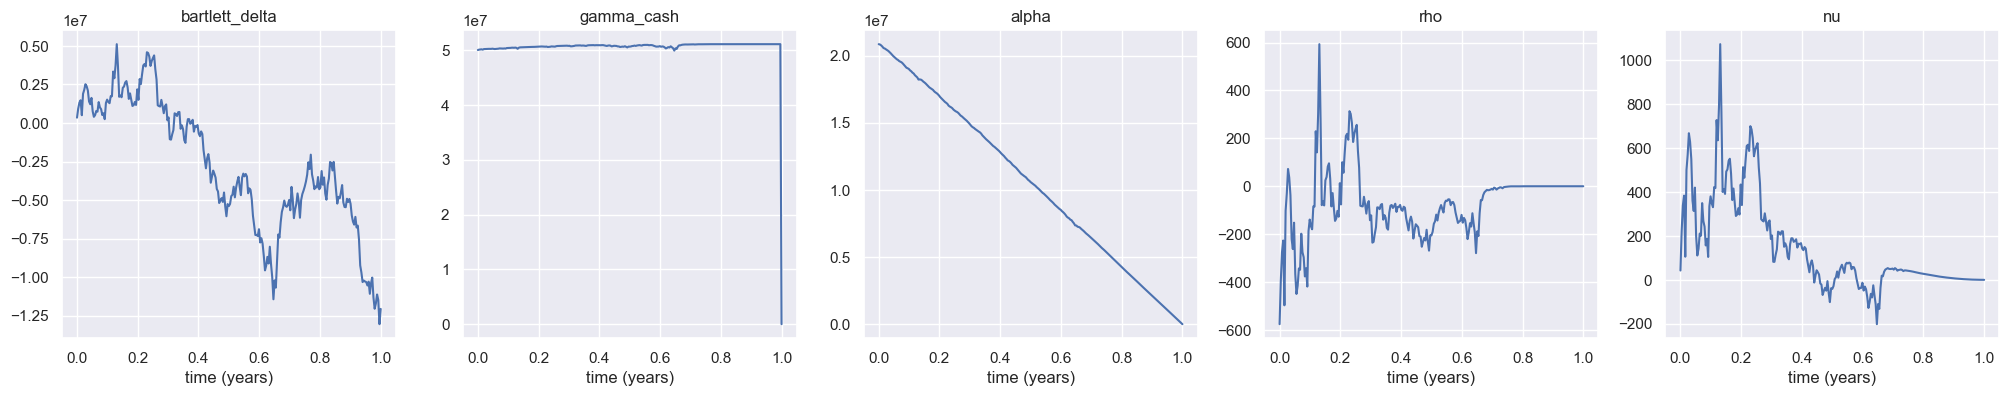

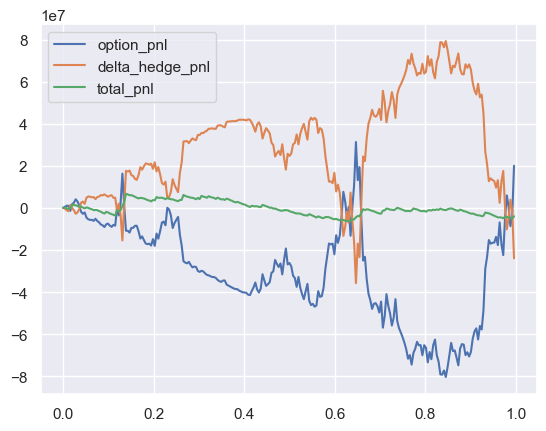

In [133]:
f_path_ts = F_paths[3]
sigma_path_ts = sigma_paths[3]
#f_path_ts.pct_change().std() * np.sqrt(252)

benchmark_weights, benchmark_risk, benchmark_pnl = benchmark_portfolio_creation(
    portfolio_type, min_delta_strike, max_delta_strike, n_options, f_path_ts, sigma_path_ts, rebalancing_frequency, sizing
)
display(benchmark_weights.replace(0, np.nan).dropna(how='all'))
display(benchmark_risk)
display(pd.concat([benchmark_pnl, benchmark_pnl.sum().to_frame("total").T]))

fig, axes = plt.subplots(1, len(benchmark_risk.columns), figsize=(25, 4))
for ax, name in zip(axes, benchmark_risk.columns):
    benchmark_risk[name].plot(ax=ax, title=name)
    ax.set_xlabel("time (years)")
plt.show()

benchmark_pnl.iloc[:-1].cumsum().plot();

### Replication Portfolio

0         0.003968  0.007937  0.0119    0.01587   \
option_type strike                                                     
call        79.62        NaN       NaN       NaN       NaN       NaN   
            80.28        NaN       NaN       NaN       NaN       NaN   
            81.39        NaN       NaN       NaN       NaN       NaN   
            81.74        NaN       NaN       NaN       NaN       NaN   
            81.77        NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
put         103          NaN       NaN       NaN       NaN       NaN   
            103.2        NaN       NaN       NaN       NaN       NaN   
            103.5        NaN       NaN       NaN       NaN       NaN   
            103.6        NaN       NaN       NaN       NaN       NaN   
            104.6        NaN       NaN       NaN       NaN       NaN   

                    0.01984   0.02381   0.02778   0.03175   0.03571   ...  \
option_type strike                                                    ...   
call        79.62        NaN       NaN       NaN       NaN       NaN  ...   
            80.28        NaN       NaN       NaN       NaN       NaN  ...   
            81.39        NaN       NaN       NaN       NaN       NaN  ...   
            81.74        NaN       NaN       NaN       NaN       NaN  ...   
            81.77        NaN       NaN       NaN       NaN       NaN  ...   
...                      ...       ...       ...       ...       ...  ...   
put         103          NaN       NaN       NaN       NaN       NaN  ...   
            103.2        NaN       NaN       NaN       NaN       NaN  ...   
            103.5        NaN       NaN       NaN       NaN       NaN  ...   
            103.6        NaN       NaN       NaN       NaN       NaN  ...   
            104.6        NaN       NaN       NaN       NaN       NaN  ...   

                      0.9643      0.9683      0.9722      0.9762    \
option_type strike                                                   
call        79.62          NaN         NaN         NaN         NaN   
            80.28          NaN         NaN         NaN         NaN   
            81.39          NaN         NaN         NaN         NaN   
            81.74          NaN         NaN         NaN         NaN   
            81.77          NaN         NaN         NaN         NaN   
...                        ...         ...         ...         ...   
put         103    -29_410_859 -29_410_859 -29_410_859 -29_410_859   
            103.2    3_273_663   3_273_663   3_273_663   3_273_663   
            103.5   -3_344_049  -3_344_049  -3_344_049  -3_344_049   
            103.6   49_604_087  49_604_087  49_604_087  49_604_087   
            104.6   94_416_913  94_416_913  94_416_913  94_416_913   

                                                             0.9802    \
option_type strike                                                      
call        79.62                                                 NaN   
            80.28                                                 NaN   
            81.39  14_452_264_653_725_154_131_059_509_813_870_101_...   
            81.74                                                 NaN   
            81.77                                                 NaN   
...                                                               ...   
put         103                                           -29_410_859   
            103.2                                           3_273_663   
            103.5                                          -3_344_049   
            103.6                                          49_604_087   
            104.6                                          94_416_913   

                                                             0.9841    \
option_type strike                                                      
call        79.62                                                 NaN   
 

,bartlett_delta,gamma_cash,alpha,rho,nu
0,-53_481_471,50_000_000,20_846_091,-575.7,42.46
0.003968,-83_758_096,50_068_395,20_821_151,-395.5,221.7
0.007937,-115_257_017,50_108_845,20_756_568,-275.7,338.6
0.0119,-131_744_964,50_131_966,20_666_103,-226.6,383.4
0.01587,-7_765_503,50_068_162,20_556_806,-496.9,105.3
...,...,...,...,...,...
0.9841,145_071_452_024_425_070_664_873_232_930_204_252...,-99_035_203_142_830_403_545_185_864_210_448_384,138_649_284_399_962_590_788_701_913_088,99_035_203_142_830_421_991_929_937_920,19_807_040_628_566_084_398_385_987_584
0.9881,5_036_975_586_177_762_772_873_188_420_009_355_3...,-2_238_195_591_027_967_241_869_711_417_639_174_144,59_421_121_885_698_253_195_157_962_752,-1_208_229_478_342_531_148_301_545_242_624,99_035_203_142_830_421_991_929_937_920
0.9921,-190_247_321_492_243_056_464_122_546_249_459_71...,-152_751_897_327_501_623_990_886_804_769_227_14...,-47_695_353_833_587_131_231_313_458_102_272,-63_461_758_173_925_734_412_428_704_219_136,-58_708_068_423_069_874_156_816_067_198_976
0.996,-7_136_746_199_660_770_733_273_542_563_215_671_...,-811_296_384_146_066_816_957_890_051_440_640_00...,324_518_553_658_426_726_783_156_020_576_256,-486_777_830_487_640_090_174_734_030_864_384,243_388_915_243_820_045_087_367_015_432_192


,option_pnl,delta_hedge_pnl,total_pnl
0,0,0,0
0.003968,-63_229_402,63_323_041,93_639
0.007937,-67_549_075,67_317_050,-232_025
0.0119,-36_900_326,36_440_778,-459_547
0.01587,261_885_971,-261_350_303,535_667
...,...,...,...
0.9881,108_547_268_776_924_649_542_747_627_500_537_319...,-108_931_903_243_333_853_668_733_976_045_074_88...,-384_634_466_409_204_125_986_348_544_537_567_18...
0.9921,-2_346_549_481_626_402_962_101_148_737_055_962_...,2_370_373_722_502_750_879_876_785_551_469_328_5...,23_824_240_876_347_917_775_636_814_413_365_667_...
0.996,380_294_287_863_087_884_741_368_102_393_881_717...,-375_140_145_530_027_034_555_591_431_540_161_95...,5_154_142_333_060_850_185_776_670_853_719_764_7...
1,-10_652_789_093_779_927_037_597_745_426_121_855...,9_579_264_897_984_698_027_821_779_345_980_104_0...,-1_073_524_195_795_229_009_775_966_080_141_751_...


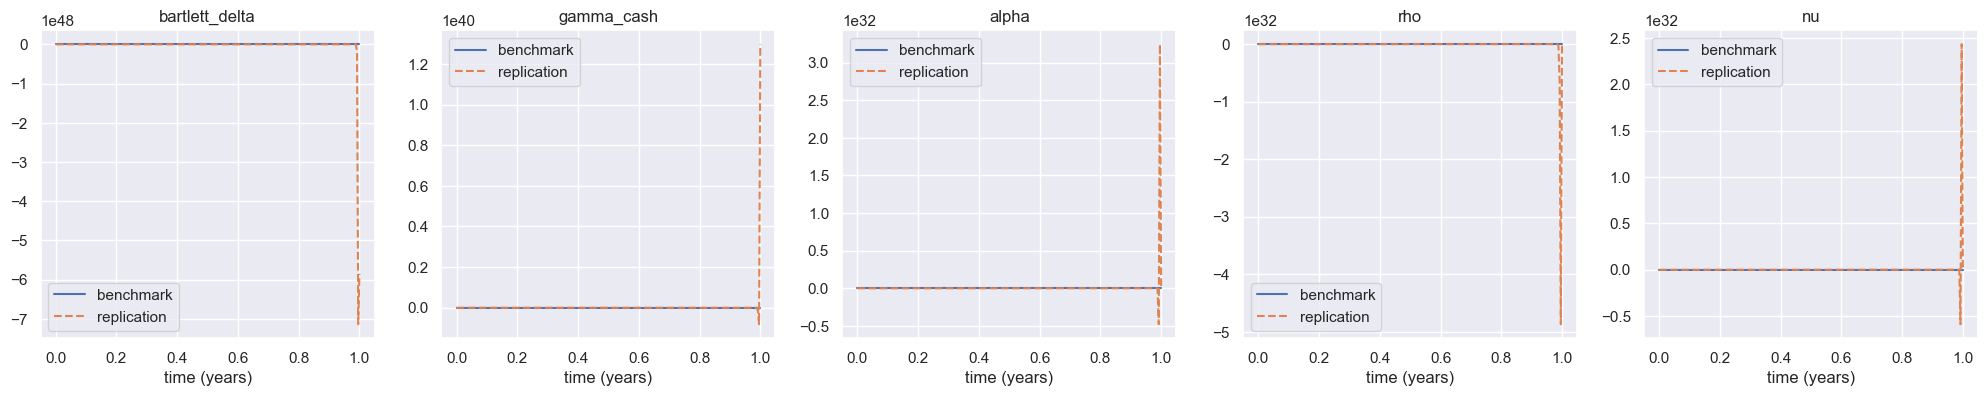

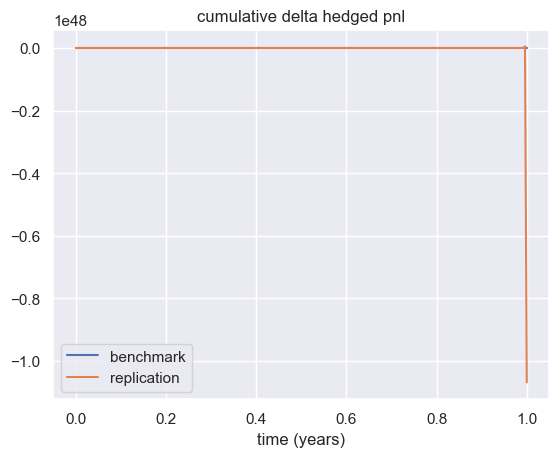

In [134]:
replication_weights, replication_risk, replication_pnl = replication_portfolio_creation(
    replication_min_delta_strike, replication_max_delta_strike, f_path_ts, sigma_path_ts,
    replication_rebalancing_frequency, benchmark_risk, replication_target_deltas
)
display(replication_weights.replace(0, np.nan).dropna(how='all'))
display(replication_risk)
display(pd.concat([replication_pnl, replication_pnl.sum().to_frame("total").T]))

fig, axes = plt.subplots(1, len(benchmark_risk.columns), figsize=(25, 4))
for ax, name in zip(axes, benchmark_risk.columns):
    benchmark_risk[name].plot(ax=ax, title=name, label="benchmark")
    replication_risk[name].plot(ax=ax, label="replication", ls="--")
    ax.set_xlabel("time (years)")
    ax.legend()
plt.show()

pd.DataFrame({
    "benchmark": benchmark_pnl["total_pnl"].cumsum(),
    "replication": replication_pnl["total_pnl"].cumsum(),
}).plot(title="cumulative delta hedged pnl", xlabel="time (years)")
plt.show()